In [23]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import sklearn
from lib.readwav import *

In [24]:

%matplotlib widget
plt.close('all')

# Ciao


questo codice funziona benissimo per segnali con frequenze molto altre (sopra i 500Hz va che è una meraviglia)

ahimè, tra tutti i file .wav ce ne sono alcuni che hanno frequenze sui 100Hz o 200Hz e in questi casi il codice non riesce ad identificare correttamente le frequenze in generale.

esempi di buon funzionamento: note_1.wav, note_104.wav, note_2.wav

esempi di cattivo funzionamento: note_72.wav, note_238.wav

per i file per cui non va bene è perchè a frequenza bassa hanno periodo maggiore, quindi nel fare l'averging taglio fuori qualcosa di troppo, quindi aumentando funziona.
Per automattizzare questa selezione si potrebbe calcolare preventivamente il periodo del segnale e scegliere la dimensione della finestra in base a questo, in modo da avere sempre un numero sufficiente di periodi all'interno di ogni finestra.

In [121]:
# leggiamo un singolo file audio
rate, note = readwav('./wav_files/note_111.wav')

In [122]:
#togliamo il primo 25% del segnale e l'ultimo 10% e plotto mantenendo i secondi corretti
note = note[:, 0] # prendo solo un canale se il segnale è stereo

start = int(len(note) * 0.25)
end = int(len(note) * 0.9)
note = note[start:end]
time = np.arange(len(note)) / rate

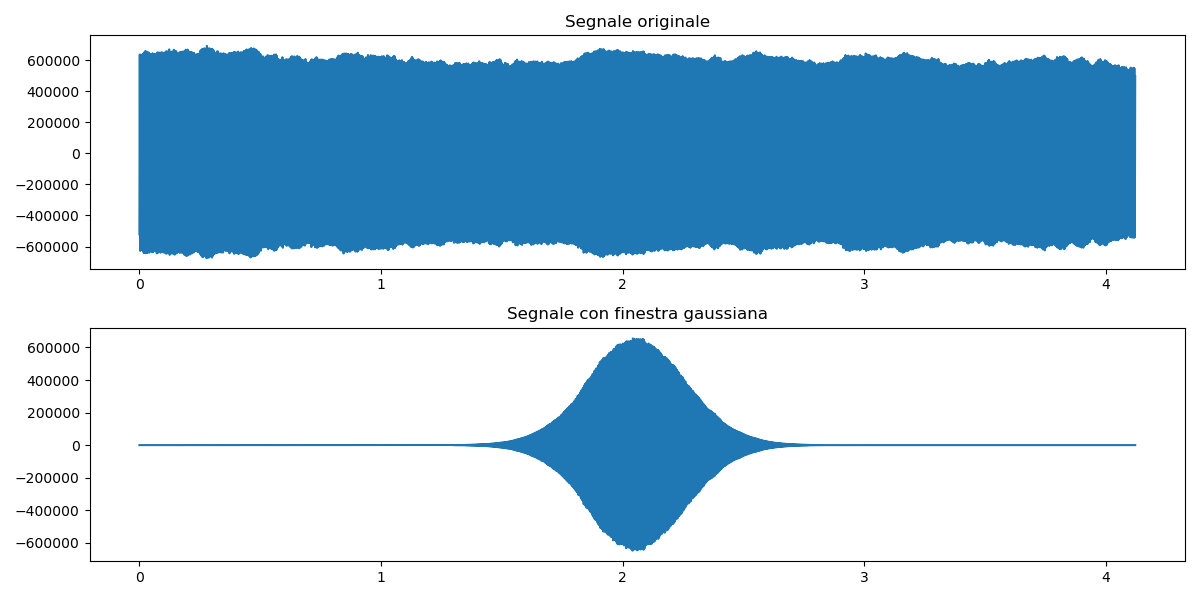

In [123]:
# Implementiamo la finestra gaussiana da applicare al segnale, in modo da attenure l'attacco e il decadimento
def gaussian_window(signal, sigma):
    n = signal.shape[0]
    x = np.arange(n)
    center = 0.5 * n
    window = np.exp(-0.5 * ((x - center) / sigma) ** 2)
    return signal * window


# applichiamo la finestra gaussiana al segnale  (sigma deve dipendere da tempo finestra)
sigma = 10000  # puoi regolare questo parametro per ottenere l'effetto desiderato
note_windowed = gaussian_window(note, sigma)

# visualizzo segnale originale e sotto segnale con fnestra gaussiana
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(time, note)
plt.title('Segnale originale')
plt.subplot(2, 1, 2)
plt.plot(time, note_windowed)
plt.title('Segnale con finestra gaussiana')
plt.tight_layout()
plt.show()


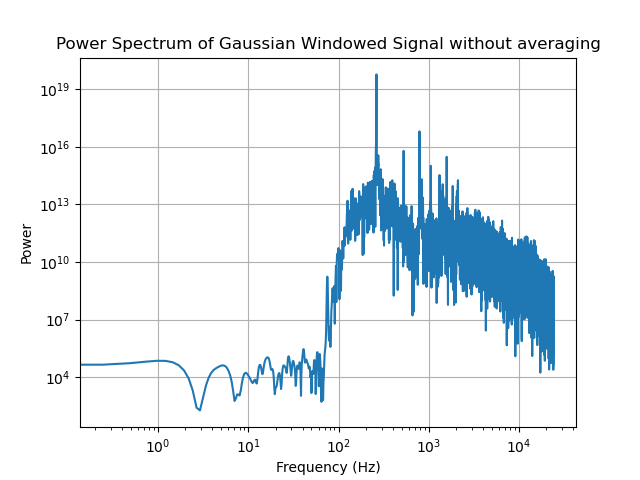

In [124]:
# vediamo come sarebbe power spectrum della finestra gaussiana senza fare la media su più finestre
fft_gaussian = np.fft.rfft(note_windowed)
power_gaussian = np.abs(fft_gaussian) ** 2
frequencies_1 = np.fft.rfftfreq(len(note_windowed), d=1/rate)
plt.figure()
plt.loglog(frequencies_1, power_gaussian)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.title('Power Spectrum of Gaussian Windowed Signal without averaging')
plt.grid()
plt.show()

In [125]:
# faccio subito il gioco della finestra gaussiana per trovare il picco e poi settare tutto su quello
window_size = 2048  # dimensione della finestra
hop_size = 512*2     # passo di sovrapposizione
num_windows = (len(note) - window_size) // hop_size + 1

#Per ogni segmento, applico la finestra gaussiana e calcolo la rfft e poi la sua potenza (modulo quadro). Sommo tutti questi spettri di potenza e divido per il numero di segmenti.
power_spectra_prev = []
for i in range(num_windows):
    start = i * hop_size
    end = start + window_size
    segment = note[start:end]
    
    # Applico la finestra gaussiana al segmento
    segment_windowed = gaussian_window(segment, 10000)
    
    # Calcolo la rfft e poi la sua potenza (modulo quadro)
    spectrum = np.fft.rfft(segment_windowed)
    power_spectrum_prev = np.abs(spectrum) ** 2
    power_spectra_prev.append(power_spectrum_prev)

# Sommo tutti questi spettri di potenza e divido per il numero di segmenti
average_power_spectrum_prev = np.mean(power_spectra_prev, axis=0)


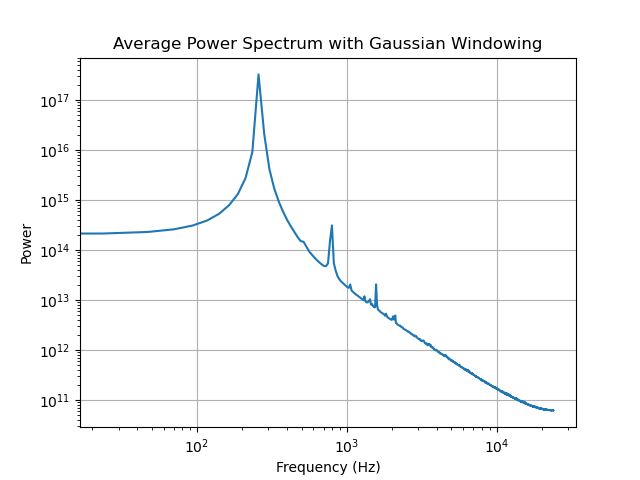

In [126]:
# visualizzo power sperctrum prev
frequencies_2 = np.fft.rfftfreq(window_size, d=1/rate)
plt.figure()
plt.loglog(frequencies_2, average_power_spectrum_prev)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.title('Average Power Spectrum with Gaussian Windowing')
plt.grid()
plt.show()

In [136]:
# vediamo subito il primo picco
# facciamo finta che il primo picco è la frequenza fondamentale (per vedere che dopo troviamo vagamente quelli corretti)
# identifichiamo i picchi per la frequenza fondamentale e le armoniche
from scipy.signal import find_peaks

prom = average_power_spectrum_prev[0] 

peaks, _ = find_peaks(average_power_spectrum_prev, prominence= prom)

fundamental_freq = frequencies_2[peaks[0]]
print('Frequenza fondamentale:', fundamental_freq, 'Hz')

if fundamental_freq < 260 and fundamental_freq > 100:
    window_size = 8192
    hop_size = 512*2  # puoi regolare anche questo se vuoi
    num_windows = (len(note) - window_size) // hop_size + 1
    power_spectra = []

    for i in range(num_windows):
        start = i * hop_size
        end = start + window_size
        segment = note[start:end]

        segment_windowed = gaussian_window(segment, 10000)
        spectrum = np.fft.rfft(segment_windowed)
        power_spectrum = np.abs(spectrum) ** 2
        power_spectra.append(power_spectrum)

    if len(power_spectra) > 0:
        average_power_spectrum = np.mean(power_spectra, axis=0)

    else:
        average_power_spectrum = None

elif fundamental_freq > 260 and fundamental_freq < 450:
    window_size = 4096
    hop_size = 512*2  # puoi regolare anche questo se vuoi
    num_windows = (len(note) - window_size) // hop_size + 1
    power_spectra = []

    for i in range(num_windows):
        start = i * hop_size
        end = start + window_size
        segment = note[start:end]

        # Considera solo segmenti della lunghezza giusta
        if len(segment) == window_size:
            segment_windowed = gaussian_window(segment, 10000)
            spectrum = np.fft.rfft(segment_windowed)
            power_spectrum = np.abs(spectrum) ** 2
            power_spectra.append(power_spectrum)

    if len(power_spectra) > 0:
        average_power_spectrum = np.mean(power_spectra, axis=0)
    
    else:
        average_power_spectrum = None

elif fundamental_freq < 100:
    window_size = 16384
    hop_size = 512*2  # puoi regolare anche questo se vuoi
    num_windows = (len(note) - window_size) // hop_size + 1
    power_spectra = []

    for i in range(num_windows):
        start = i * hop_size
        end = start + window_size
        segment = note[start:end]

        # Considera solo segmenti della lunghezza giusta
        if len(segment) == window_size:
            segment_windowed = gaussian_window(segment, 10000)
            spectrum = np.fft.rfft(segment_windowed)
            power_spectrum = np.abs(spectrum) ** 2
            power_spectra.append(power_spectrum)

    if len(power_spectra) > 0:
        average_power_spectrum = np.mean(power_spectra, axis=0)
    
    else:
        average_power_spectrum = None
else:
    power_spectra = power_spectra_prev
    average_power_spectrum = np.mean(power_spectra, axis=0)
    


Frequenza fondamentale: 257.8125 Hz


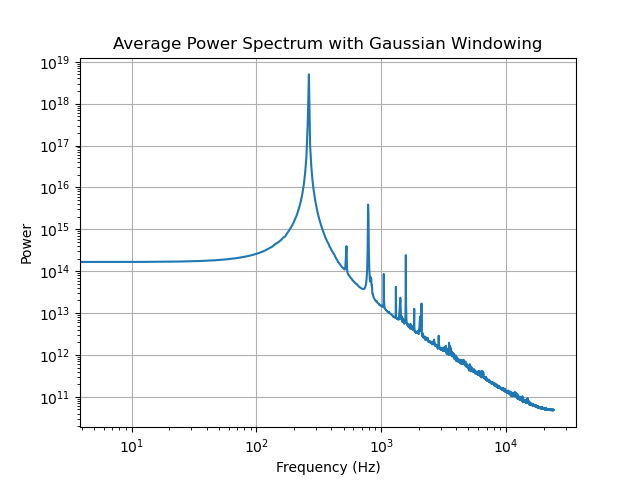

In [137]:
# visualizzo power sperctrum prev
frequencies = np.fft.rfftfreq(segment_windowed.shape[0], d=1/rate)
plt.figure()
plt.loglog(frequencies, average_power_spectrum)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.title('Average Power Spectrum with Gaussian Windowing')
plt.grid()
plt.show()

prominence =  100000000000000.0 , altezza =  165860524172727.62
Frequenza fondamentale: 263.671875 Hz


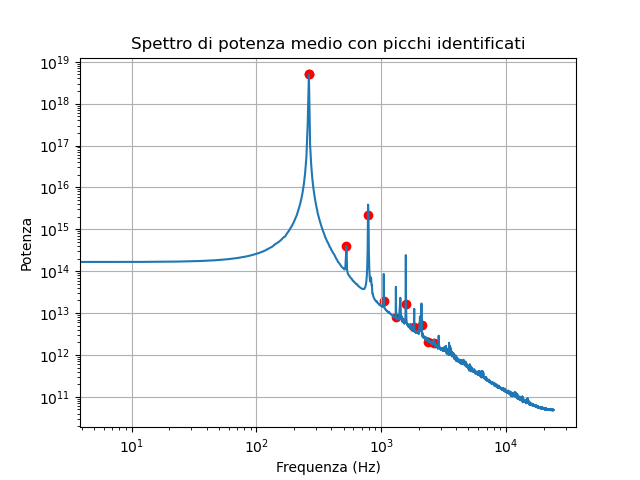

In [138]:
# facciamo finta che il primo picco è la frequenza fondamentale (per vedere che dopo troviamo vagamente quelli corretti)
# identifichiamo i picchi per la frequenza fondamentale e le armoniche
from scipy.signal import find_peaks

#prendo come prominence il valore inferiore dell'intervallo in cui si trova average_power_spectrum, in modo da escludere picchi che sono troppo vicini tra loro
prom = 10**(np.floor(np.log10(average_power_spectrum[0])))
altezza = average_power_spectrum[0]

print('prominence = ', prom, ', altezza = ', altezza)

from scipy.signal import find_peaks
peaks, _ = find_peaks(average_power_spectrum, prominence= prom, height=altezza)

fundamental_freq = frequencies[peaks[0]]
print('Frequenza fondamentale:', fundamental_freq, 'Hz')

# Ora troviamo le successive armoniche, che dovrebbero essere multipli interi della frequenza fondamentale (entro una tolleranza)
tolerance = 20  # in Hz
harmonics = []
for i in range(1, 11):  # cerchiamo fino alla decima armonica
    target_freq = i * fundamental_freq
    # Troviamo il picco più vicino a target_freq
    idx = np.argmin(np.abs(frequencies - target_freq))
    if np.abs(frequencies[idx] - target_freq) < tolerance:
        harmonics.append(frequencies[idx])

#segnamole sul grafico
plt.figure()
plt.loglog(frequencies, average_power_spectrum)
plt.scatter([fundamental_freq] + harmonics, [average_power_spectrum[np.argmin(np.abs(frequencies - fundamental_freq))]] + [average_power_spectrum[np.argmin(np.abs(frequencies - h))] for h in harmonics], color='red')
plt.title('Spettro di potenza medio con picchi identificati')
plt.xlabel('Frequenza (Hz)')
plt.ylabel('Potenza')
plt.grid()
plt.show()



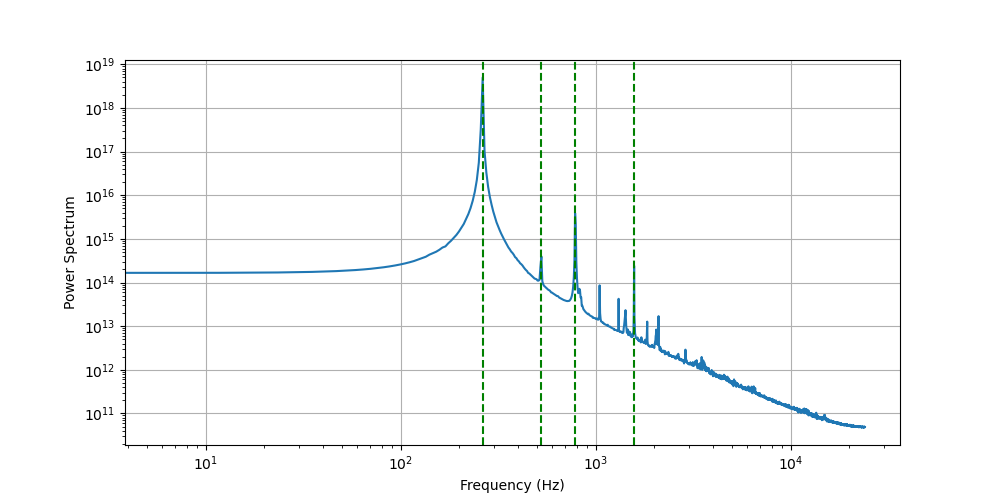

In [139]:
# identifichiamo i picchi per la frequenza fondamentale e le armoniche
# potrebbe essere che la frequenza fondamentale non sia il picco più alto, quindi dobbiamo cercare i picchi e poi identificare la frequenza fondamentale in base alla distanza tra i picchi
from scipy.signal import find_peaks
peaks, _ = find_peaks(average_power_spectrum, prominence= prom)

#inserisco una tolleranza per identificare la frequenza fondamentale, in modo da escludere picchi che sono troppo vicini tra loro
#controllo: se frequenza bassa tolleranza sono 50 Hz, altrimenti 100 Hz
if fundamental_freq < 500:
    tolerance = 20
else:
    tolerance = 100 # in Hz

picchi_freq = []
for peak in peaks:
    freq = frequencies[peak]
    if all(abs(freq - f) > tolerance for f in picchi_freq):
        picchi_freq.append(freq)
    freq_max = frequencies[np.argmax(average_power_spectrum)]



# evidenziamo i primi 6 picchi sul grafico
plt.figure(figsize=(10, 5))
plt.loglog(frequencies, average_power_spectrum)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectrum")
plt.grid()
for f in picchi_freq[:20]:  
    plt.axvline(f, color='g', linestyle='--')
plt.show()

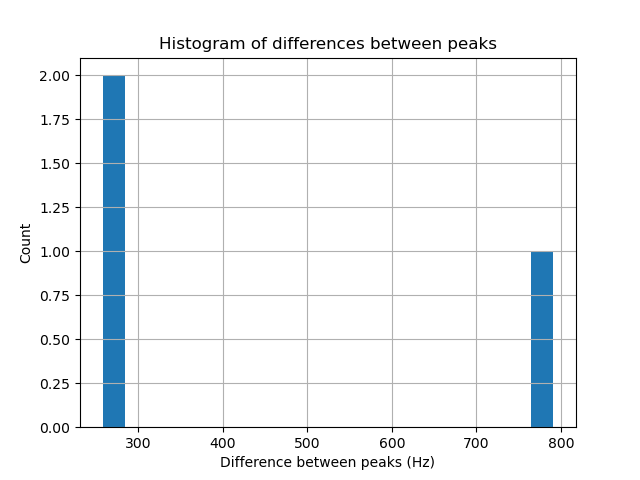

In [140]:
# calcoliamo la differenza tra una armonica e la successiva dei 6 picchi, in modo da identificare la frequenza fondamentale come il massimo comun divisore tra i picchi
diffs = np.diff(picchi_freq[:20])
plt.figure()
plt.hist(diffs, bins=20)
plt.xlabel('Difference between peaks (Hz)')
plt.ylabel('Count')
plt.title('Histogram of differences between peaks')
plt.grid()
plt.show()

In [141]:
# maschera per prendere solo le differenze giuste (cioè quelle del bin più elevato)
counts, bin_edges = np.histogram(diffs, bins=20) 

# Indice del bin con più occorrenze
idx_max = np.argmax(counts)
print(" Bin con più occorrenze:", idx_max, "con", counts[idx_max], "occurrences")

soglia_min = bin_edges[idx_max]
soglia_max = bin_edges[idx_max + 1]
differenze_nel_picco = diffs[(diffs >= soglia_min) & (diffs <= soglia_max)]

# La tua frequenza fondamentale stimata
f0_stimata = np.mean(differenze_nel_picco)
f0_sigma = np.std(differenze_nel_picco)

print('Soglia minima:', soglia_min, 'Hz')
print('Soglia massima:', soglia_max, 'Hz')

print('Frequenza fondamentale stimata:', f0_stimata, 'Hz')
print('Deviazione standard della stima:', f0_sigma, 'Hz')

 Bin con più occorrenze: 0 con 2 occurrences
Soglia minima: 257.8125 Hz
Soglia massima: 284.47265625 Hz
Frequenza fondamentale stimata: 260.7421875 Hz
Deviazione standard della stima: 2.9296875 Hz


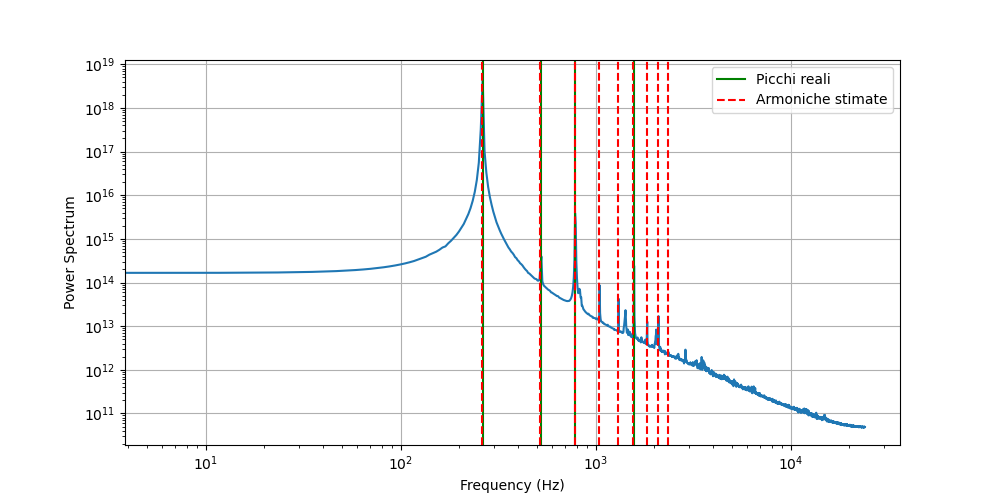

In [142]:
# dalla fondamentale calcolo le armoniche successive 
harmonics_estimate = [f0_stimata * i for i in range(1, 10)]

# ora voglio vedere se queste armoniche stimate sono vicine ai picchi che ho trovato prima
# in modo da salvare le armoniche reali presenti nel segnale
harmonics_array = []
harmonics_real = []
tolerance_harmonics = 30  # in Hz
for h in harmonics_estimate:
    found = False
    for f in picchi_freq[:20]:
        if abs(f - h) < tolerance_harmonics:
            harmonics_real.append(f)
            harmonics_array.append(f)
            found = True
            break
    if not found:
        harmonics_array.append(h)
        harmonics_real.append(None)

# visualizzo le armoniche stimate e quelle reali sul grafico
plt.figure(figsize=(10, 5))
plt.loglog(frequencies, average_power_spectrum)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectrum")
plt.grid()
# Solo valori validi (non None) per le armoniche reali
for f in harmonics_real[:20]:  
    if f is not None:
        plt.axvline(f, color='g', linestyle='-', label='Picchi reali' if f == harmonics_real[0] else "")
for h in harmonics_estimate:
    plt.axvline(h, color='r', linestyle='--', label='Armoniche stimate' if h == harmonics_estimate[0] else "")
plt.legend()
plt.show()

In [143]:
n_armoniche = 6
harmonics_power_spectrum = []

# salvo i valori di power spectrum per le armoniche stimati
# in pratica per ogni armonica salvo il valore del power spectrum della frequenza che sto considerando
# se ho una armonica molto vicina a quella stimata, prendo il valore del power spectrum di quella frequenza, altrimenti prendo il valore del power spectrum alla frequenza stimata (quindi il rumore di fondo)
# uso l'array con tutte le frequenze (harmonics_array) 

intorno = 5 

for i in range(n_armoniche):
    f_target = harmonics_array[i]
    
    idx_target = np.argmin(np.abs(frequencies - f_target))
    
    start = max(0, idx_target - intorno)
    end = min(len(average_power_spectrum), idx_target + intorno + 1)
    
    valore_potenza = np.max(average_power_spectrum[start:end])
    harmonics_power_spectrum.append(valore_potenza)

# 4. Normalizzazione per il K-means (Il DNA del timbro)
# Dividiamo tutto per la potenza della fondamentale (il primo elemento)
#A1 = harmonics_power_spectrum[0]
#harmonics_normalizzati = [p / A1 for p in harmonics_power_spectrum]

# Verifichiamo cosa abbiamo ottenuto
for i in range(n_armoniche):
    print(f"Armonica {i+1}: {harmonics_array[i]:.2f} Hz | Potenza Relativa: {harmonics_power_spectrum[i]:.2e}")

Armonica 1: 263.67 Hz | Potenza Relativa: 5.00e+18
Armonica 2: 527.34 Hz | Potenza Relativa: 3.96e+14
Armonica 3: 785.16 Hz | Potenza Relativa: 3.89e+15
Armonica 4: 1042.97 Hz | Potenza Relativa: 8.60e+13
Armonica 5: 1303.71 Hz | Potenza Relativa: 4.23e+13
Armonica 6: 1576.17 Hz | Potenza Relativa: 2.42e+14


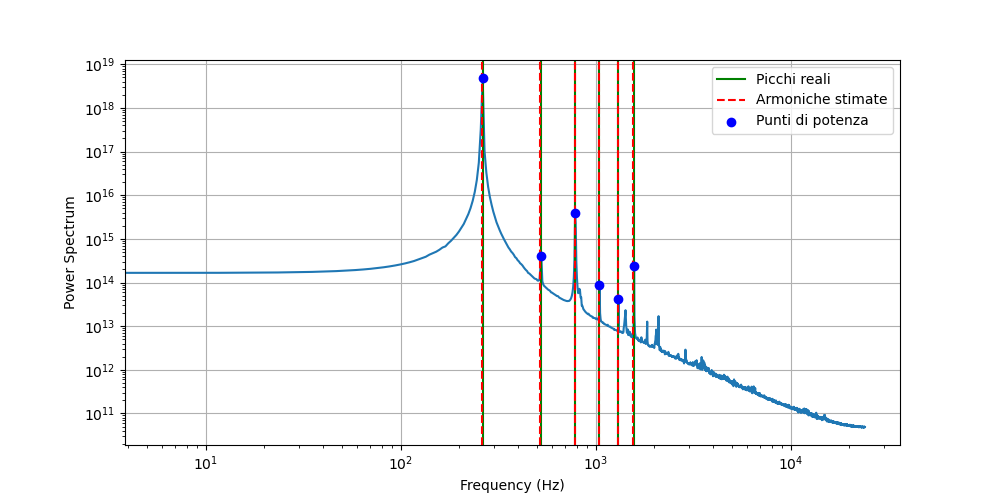

In [144]:
# voglio vedere i punti di power spectrum in corrispondenza delle frequenze che mi trova
plt.figure(figsize=(10, 5))
plt.loglog(frequencies, average_power_spectrum)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectrum")
plt.grid()
for i in range(n_armoniche):
    f = harmonics_array[i]
    if f is not None:
        plt.axvline(f, color='g', linestyle='-', label='Picchi reali' if i == 0 else "")
    h = harmonics_estimate[i]
    plt.axvline(h, color='r', linestyle='--', label='Armoniche stimate' if i == 0 else "")
    plt.scatter(f, harmonics_power_spectrum[i], color='blue', zorder=5, label='Punti di potenza' if i == 0 else "")
plt.legend()
plt.show()